In [2]:
import pyro
import pyro.distributions as dist
import torch
import numpy as np
import matplotlib.pylab as plt

In [3]:
N = 1000
D = 3

In [9]:
K = 2

In [10]:
X = torch.zeros(N,D)

In [11]:
def model(X):
    with pyro.plate('D', D):
        with pyro.plate('K', K):
            W = pyro.sample('W', dist.Normal(0,1))
        Sigma = pyro.sample('Sigma', dist.LogNormal(0,1))
    diag = torch.diag_embed(Sigma)
    with pyro.plate('N', N):
        with pyro.plate('K2', K):
            z = pyro.sample('z', dist.Normal(0,1))
        Wz = torch.matmul(z.transpose(0,1), W)
        X = pyro.sample('obs', dist.MultivariateNormal(Wz, diag), obs=X)
    return X

In [12]:
X = pyro.poutine.uncondition(model)(X)

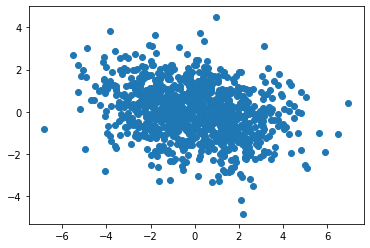

In [13]:
plt.scatter(*X[:,:2].T.detach())